In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce


import dask
import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Load Augmented DF

In [2]:
augmented_df = dd.read_csv("../../data/augmented_us-counties_latest.csv", assume_missing=True).compute()
augmented_df["date"] = pd.to_datetime(augmented_df["date"])
augmented_df["fips"] = augmented_df["fips"].astype(int)
augmented_df["days_from_start"] = augmented_df["days_from_start"].astype(int)
augmented_df["log_rolled_cases"] = np.log(augmented_df["rolled_cases"] + 1.1)
augmented_df = augmented_df.sort_values(by=["fips","date"])

# Generate 7 day validation data
for shift in range(1,8):
    augmented_df["shifted_log_rolled_cases_{}".format(shift)] = augmented_df.groupby("fips")["log_rolled_cases"].shift(-shift)

# Check for gaps
gt_columns = ["fips", "days_from_start", "date", "log_rolled_cases"] + ["shifted_log_rolled_cases_{}".format(shift) for shift in range(1,8)]
augmented_df_gt = augmented_df[gt_columns]
grouped = augmented_df_gt.groupby('fips')

for fips, group in grouped:
    missing_days = group['days_from_start'].diff().gt(1).sum()
    if missing_days > 0:
        print(f"Gap(s) found in 'days_from_start' for fips {fips}: {missing_days} gap(s)")


#df = augmented_df.copy()
window_sizes = list(range(2,15))
fips_list = augmented_df_gt["fips"].unique()

### Load all $r_{t,c}$

In [3]:
all_beta_df = dd.read_csv("../benchmark_fixed_window/Fixed_windows_all_beta.csv",assume_missing=True).compute()
all_beta_df["date"] = pd.to_datetime(all_beta_df["date"])
all_beta_df = all_beta_df.sort_values(by=["fips","date"])
(all_beta_df.head())

,fips,days_from_start,date,log_rolled_cases,shifted_log_rolled_cases,beta_wsize=2,beta_wsize=3,beta_wsize=4,beta_wsize=5,beta_wsize=6,beta_wsize=7,beta_wsize=8,beta_wsize=9,beta_wsize=10,beta_wsize=11,beta_wsize=12,beta_wsize=13,beta_wsize=14
0,1001.0,69.0,2020-03-30,1.831438,2.469309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1001.0,70.0,2020-03-31,1.960095,2.528012,0.128657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1001.0,71.0,2020-04-01,2.074070,2.550561,0.113975,0.121316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1001.0,72.0,2020-04-02,2.143422,2.625703,0.069352,0.091664,0.104993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1001.0,73.0,2020-04-03,2.239189,2.676117,0.095767,0.082559,0.090663,0.099883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Add Predictions

In [4]:
all_beta_df_results = all_beta_df.copy()
window_sizes = range(2,15)
for window_size in window_sizes:
    for shift in range(1,8):
        all_beta_df_results["predicted_beta_wsize={}_shift={}".format(window_size, shift)] = all_beta_df_results["beta_wsize={}".format(window_size)]*shift + all_beta_df_results["log_rolled_cases"]
all_beta_df_results = all_beta_df_results.drop(columns=["date","log_rolled_cases", "shifted_log_rolled_cases"])
all_beta_df_results = pd.merge(augmented_df_gt, all_beta_df_results, on=["fips", "days_from_start"], how="left")
all_beta_df_results

,fips,days_from_start,date,log_rolled_cases,shifted_log_rolled_cases_1,shifted_log_rolled_cases_2,shifted_log_rolled_cases_3,shifted_log_rolled_cases_4,shifted_log_rolled_cases_5,shifted_log_rolled_cases_6,shifted_log_rolled_cases_7,beta_wsize=2,beta_wsize=3,beta_wsize=4,beta_wsize=5,beta_wsize=6,beta_wsize=7,beta_wsize=8,beta_wsize=9,beta_wsize=10,beta_wsize=11,beta_wsize=12,beta_wsize=13,beta_wsize=14,predicted_beta_wsize=2_shift=1,predicted_beta_wsize=2_shift=2,predicted_beta_wsize=2_shift=3,predicted_beta_wsize=2_shift=4,predicted_beta_wsize=2_shift=5,predicted_beta_wsize=2_shift=6,predicted_beta_wsize=2_shift=7,predicted_beta_wsize=3_shift=1,predicted_beta_wsize=3_shift=2,predicted_beta_wsize=3_shift=3,predicted_beta_wsize=3_shift=4,predicted_beta_wsize=3_shift=5,predicted_beta_wsize=3_shift=6,predicted_beta_wsize=3_shift=7,predicted_beta_wsize=4_shift=1,predicted_beta_wsize=4_shift=2,predicted_beta_wsize=4_shift=3,predicted_beta_wsize=4_shift=4,predicted_beta_wsize=4_shift=5,predicted_beta_wsize=4_shift=6,predicted_beta_wsize=4_shift=7,predicted_beta_wsize=5_shift=1,predicted_beta_wsize=5_shift=2,predicted_beta_wsize=5_shift=3,predicted_beta_wsize=5_shift=4,predicted_beta_wsize=5_shift=5,predicted_beta_wsize=5_shift=6,predicted_beta_wsize=5_shift=7,predicted_beta_wsize=6_shift=1,predicted_beta_wsize=6_shift=2,predicted_beta_wsize=6_shift=3,predicted_beta_wsize=6_shift=4,predicted_beta_wsize=6_shift=5,predicted_beta_wsize=6_shift=6,predicted_beta_wsize=6_shift=7,predicted_beta_wsize=7_shift=1,predicted_beta_wsize=7_shift=2,predicted_beta_wsize=7_shift=3,predicted_beta_wsize=7_shift=4,predicted_beta_wsize=7_shift=5,predicted_beta_wsize=7_shift=6,predicted_beta_wsize=7_shift=7,predicted_beta_wsize=8_shift=1,predicted_beta_wsize=8_shift=2,predicted_beta_wsize=8_shift=3,predicted_beta_wsize=8_shift=4,predicted_beta_wsize=8_shift=5,predicted_beta_wsize=8_shift=6,predicted_beta_wsize=8_shift=7,predicted_beta_wsize=9_shift=1,predicted_beta_wsize=9_shift=2,predicted_beta_wsize=9_shift=3,predicted_beta_wsize=9_shift=4,predicted_beta_wsize=9_shift=5,predicted_beta_wsize=9_shift=6,predicted_beta_wsize=9_shift=7,predicted_beta_wsize=10_shift=1,predicted_beta_wsize=10_shift=2,predicted_beta_wsize=10_shift=3,predicted_beta_wsize=10_shift=4,predicted_beta_wsize=10_shift=5,predicted_beta_wsize=10_shift=6,predicted_beta_wsize=10_shift=7,predicted_beta_wsize=11_shift=1,predicted_beta_wsize=11_shift=2,predicted_beta_wsize=11_shift=3,predicted_beta_wsize=11_shift=4,predicted_beta_wsize=11_shift=5,predicted_beta_wsize=11_shift=6,predicted_beta_wsize=11_shift=7,predicted_beta_wsize=12_shift=1,predicted_beta_wsize=12_shift=2,predicted_beta_wsize=12_shift=3,predicted_beta_wsize=12_shift=4,predicted_beta_wsize=12_shift=5,predicted_beta_wsize=12_shift=6,predicted_beta_wsize=12_shift=7,predicted_beta_wsize=13_shift=1,predicted_beta_wsize=13_shift=2,predicted_beta_wsize=13_shift=3,predicted_beta_wsize=13_shift=4,predicted_beta_wsize=13_shift=5,predicted_beta_wsize=13_shift=6,predicted_beta_wsize=13_shift=7,predicted_beta_wsize=14_shift=1,predicted_beta_wsize=14_shift=2,predicted_beta_wsize=14_shift=3,predicted_beta_wsize=14_shift=4,predicted_beta_wsize=14_shift=5,predicted_beta_wsize=14_shift=6,predicted_beta_wsize=14_shift=7
0,1001,69,2020-03-30,1.831438,1.960095,2.074070,2.143422,2.239189,2.326581,2.406945,2.469309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1001,70,2020-03-31,1.960095,2.074070,2.143422,2.239189,2.326581,2.406945,2.469309,2.528012,0.128657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.088752,2.217408,2.346065,2.474722,2.603379,2.732036,2.860693,NaN,NaN,NaN,NaN

### Calculate per day RMSE and MAE, and Cumulative of both

In [5]:
indexing_columns = ["days_from_start","date"]
daily_metrics_df = all_beta_df_results[indexing_columns].drop_duplicates()
daily_metrics_df = daily_metrics_df.sort_values(by="days_from_start")
daily_metrics_df = daily_metrics_df.reset_index(drop=True)

wsize_shift = itertools.product(list(window_sizes), list(range(1,8)))


for window_size in tqdm(window_sizes):
    for shift in range(1, 8):
        all_beta_df_results["diff_wsize={}_shift={}".format(window_size, shift)] = all_beta_df_results["predicted_beta_wsize={}_shift={}".format(window_size,shift)] - all_beta_df_results["shifted_log_rolled_cases_{}".format(shift)]
    rmse = all_beta_df_results.groupby("date").apply(lambda x : np.sqrt(np.nanmean(np.square(x[["diff_wsize={}_shift={}".format(window_size, s) for s in range(1,8)]]))))
    mae = all_beta_df_results.groupby("date").apply(lambda x : np.nanmean(np.abs(x[["diff_wsize={}_shift={}".format(window_size, s) for s in range(1,8)]])))
    
    rmse = pd.DataFrame(rmse).reset_index().rename(columns={0:"rmse_wsize={}".format(window_size)})
    mae = pd.DataFrame(mae).reset_index().rename(columns={0:"mae_wsize={}".format(window_size)})
    
    daily_metrics_df = pd.merge(daily_metrics_df, mae, on="date", how="left")
    daily_metrics_df = pd.merge(daily_metrics_df, rmse, on="date", how="left")
    
    
    daily_metrics_df["cumsum_mae_wsize={}".format(window_size)] = daily_metrics_df["mae_wsize={}".format(window_size)].cumsum()
    daily_metrics_df["cumsum_rmse_wsize={}".format(window_size)] = daily_metrics_df["rmse_wsize={}".format(window_size)].cumsum()
    

In [6]:
daily_metrics_df

,days_from_start,date,mae_wsize=2,rmse_wsize=2,cumsum_mae_wsize=2,cumsum_rmse_wsize=2,mae_wsize=3,rmse_wsize=3,cumsum_mae_wsize=3,cumsum_rmse_wsize=3,mae_wsize=4,rmse_wsize=4,cumsum_mae_wsize=4,cumsum_rmse_wsize=4,mae_wsize=5,rmse_wsize=5,cumsum_mae_wsize=5,cumsum_rmse_wsize=5,mae_wsize=6,rmse_wsize=6,cumsum_mae_wsize=6,cumsum_rmse_wsize=6,mae_wsize=7,rmse_wsize=7,cumsum_mae_wsize=7,cumsum_rmse_wsize=7,mae_wsize=8,rmse_wsize=8,cumsum_mae_wsize=8,cumsum_rmse_wsize=8,mae_wsize=9,rmse_wsize=9,cumsum_mae_wsize=9,cumsum_rmse_wsize=9,mae_wsize=10,rmse_wsize=10,cumsum_mae_wsize=10,cumsum_rmse_wsize=10,mae_wsize=11,rmse_wsize=11,cumsum_mae_wsize=11,cumsum_rmse_wsize=11,mae_wsize=12,rmse_wsize=12,cumsum_mae_wsize=12,cumsum_rmse_wsize=12,mae_wsize=13,rmse_wsize=13,cumsum_mae_wsize=13,cumsum_rmse_wsize=13,mae_wsize=14,rmse_wsize=14,cumsum_mae_wsize=14,cumsum_rmse_wsize=14
0,6,2020-01-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7,2020-01-28,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8,2020-01-29,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9,2020-01-30,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10,2020-01-31,0.028002,0.056417,0.028002,0.056417,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,1153,2023-03-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1148,1154,2023-03-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1149,1155,2023-03-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1150,1156,2023-03-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


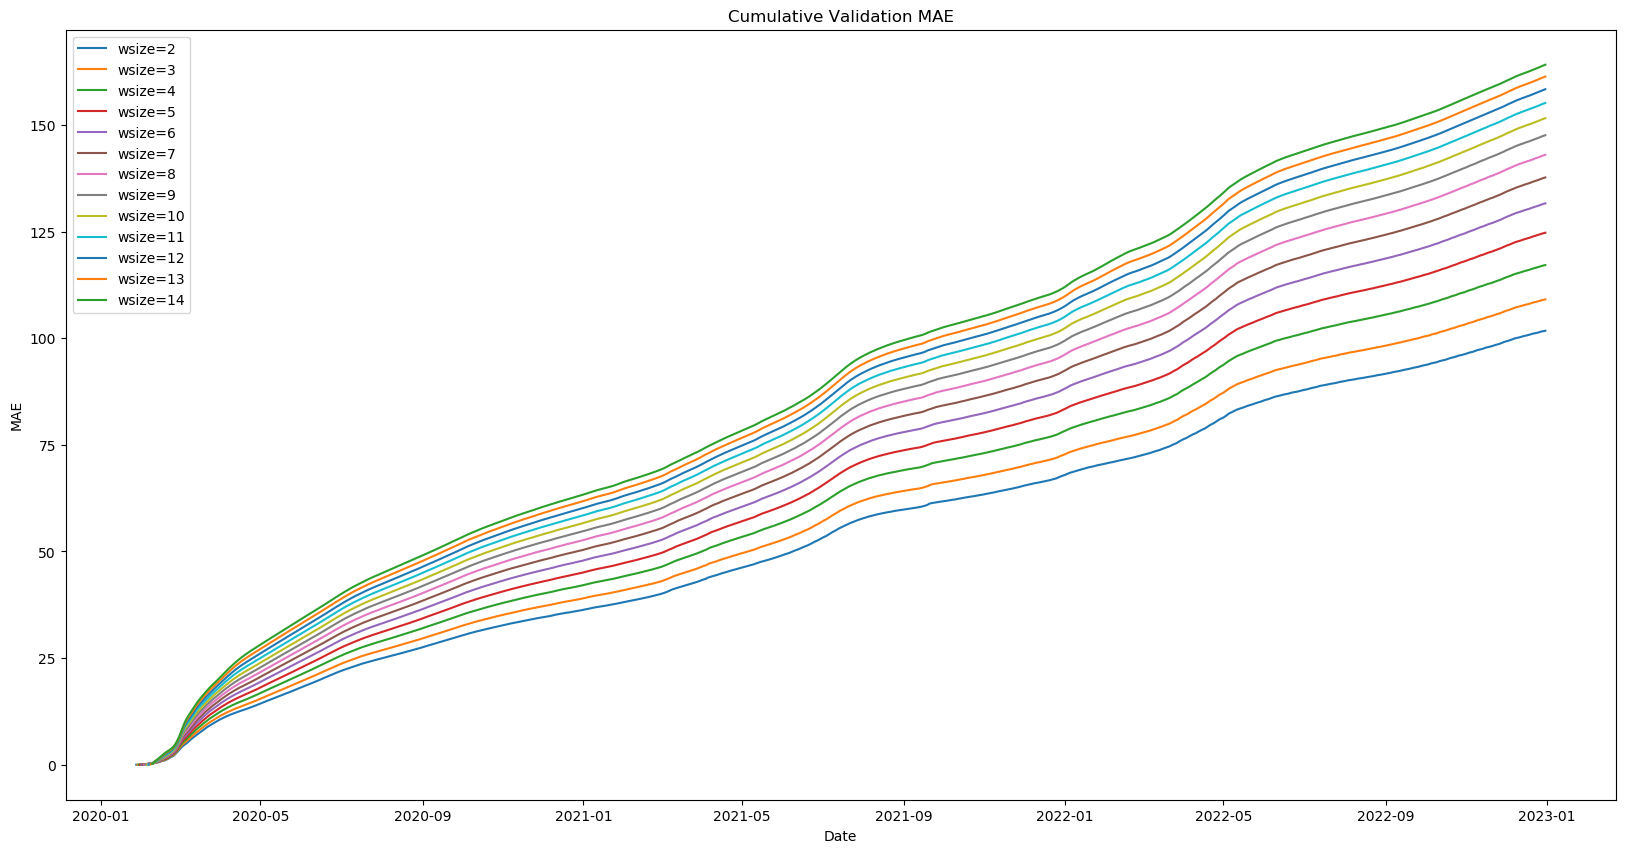

In [7]:
plt.figure(figsize=(20,10))
for wsize in window_sizes:
    plt.plot(daily_metrics_df["date"], daily_metrics_df["cumsum_mae_wsize={}".format(wsize)], label="wsize={}".format(wsize))
    plt.xlabel("Date")
    plt.ylabel("MAE")
    plt.legend()
    plt.title("Cumulative Validation MAE")
plt.show()

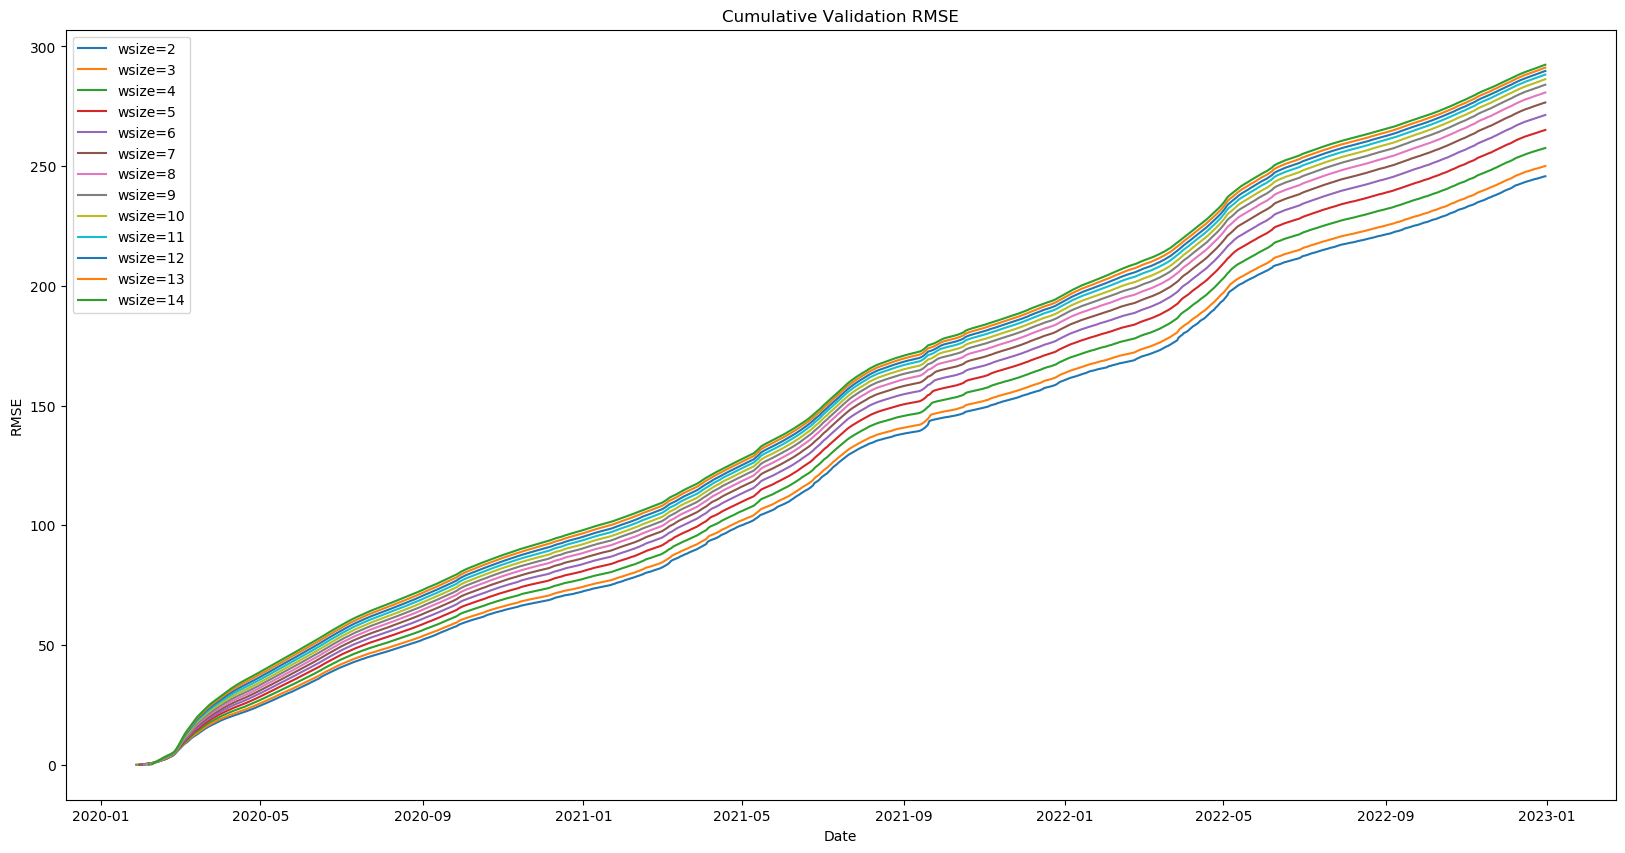

In [8]:
plt.figure(figsize=(20,10))
for wsize in window_sizes:
    plt.plot(daily_metrics_df["date"], daily_metrics_df["cumsum_rmse_wsize={}".format(wsize)], label="wsize={}".format(wsize))
    plt.xlabel("Date")
    plt.ylabel("RMSE")
    plt.legend()
    plt.title("Cumulative Validation RMSE")
plt.show()

In [9]:
median_daily_metrics_df = pd.DataFrame(columns=["MAE","RMSE"])
for window_size in window_sizes:
    entry = [daily_metrics_df["mae_wsize={}".format(window_size)].median(), daily_metrics_df["rmse_wsize={}".format(window_size)].median()]
    median_daily_metrics_df.loc[len(median_daily_metrics_df)] = entry
median_daily_metrics_df.index = ["Fixed Window {}".format(window_size) for window_size in window_sizes]


In [10]:
median_daily_metrics_df

,MAE,RMSE
Fixed Window 2,0.084783,0.203268
Fixed Window 3,0.091434,0.205876
Fixed Window 4,0.098356,0.212826
Fixed Window 5,0.104206,0.217804
Fixed Window 6,0.109955,0.224620
Fixed Window 7,0.115364,0.229446
Fixed Window 8,0.120621,0.233464
Fixed Window 9,0.124164,0.235757
Fixed Window 10,0.127394,0.237864
Fixed Window 11,0.130204,0.238794


In [11]:
1 + np.nan

nan

In [12]:
all_beta_df_results[["diff_wsize={}_shift={}".format(2,s) for s in range(1,8)]]

,diff_wsize=2_shift=1,diff_wsize=2_shift=2,diff_wsize=2_shift=3,diff_wsize=2_shift=4,diff_wsize=2_shift=5,diff_wsize=2_shift=6,diff_wsize=2_shift=7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.014682,0.073987,0.106877,0.148142,0.196434,0.262726,0.332681
2,0.044623,0.062832,0.089415,0.123026,0.174637,0.229910,0.321336
3,-0.026415,-0.044455,-0.055468,-0.048480,-0.037831,0.008972,0.003182
4,0.008375,0.023777,0.057180,0.094245,0.167463,0.188087,0.233440
...,...,...,...,...,...,...,...
3390311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3390312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3390313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3390314,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
wsize2_mae = all_beta_df_results.groupby("date").apply(lambda x : np.nanmean(np.abs(x[["diff_wsize={}_shift={}".format(2,s) for s in range(1,8)]])))

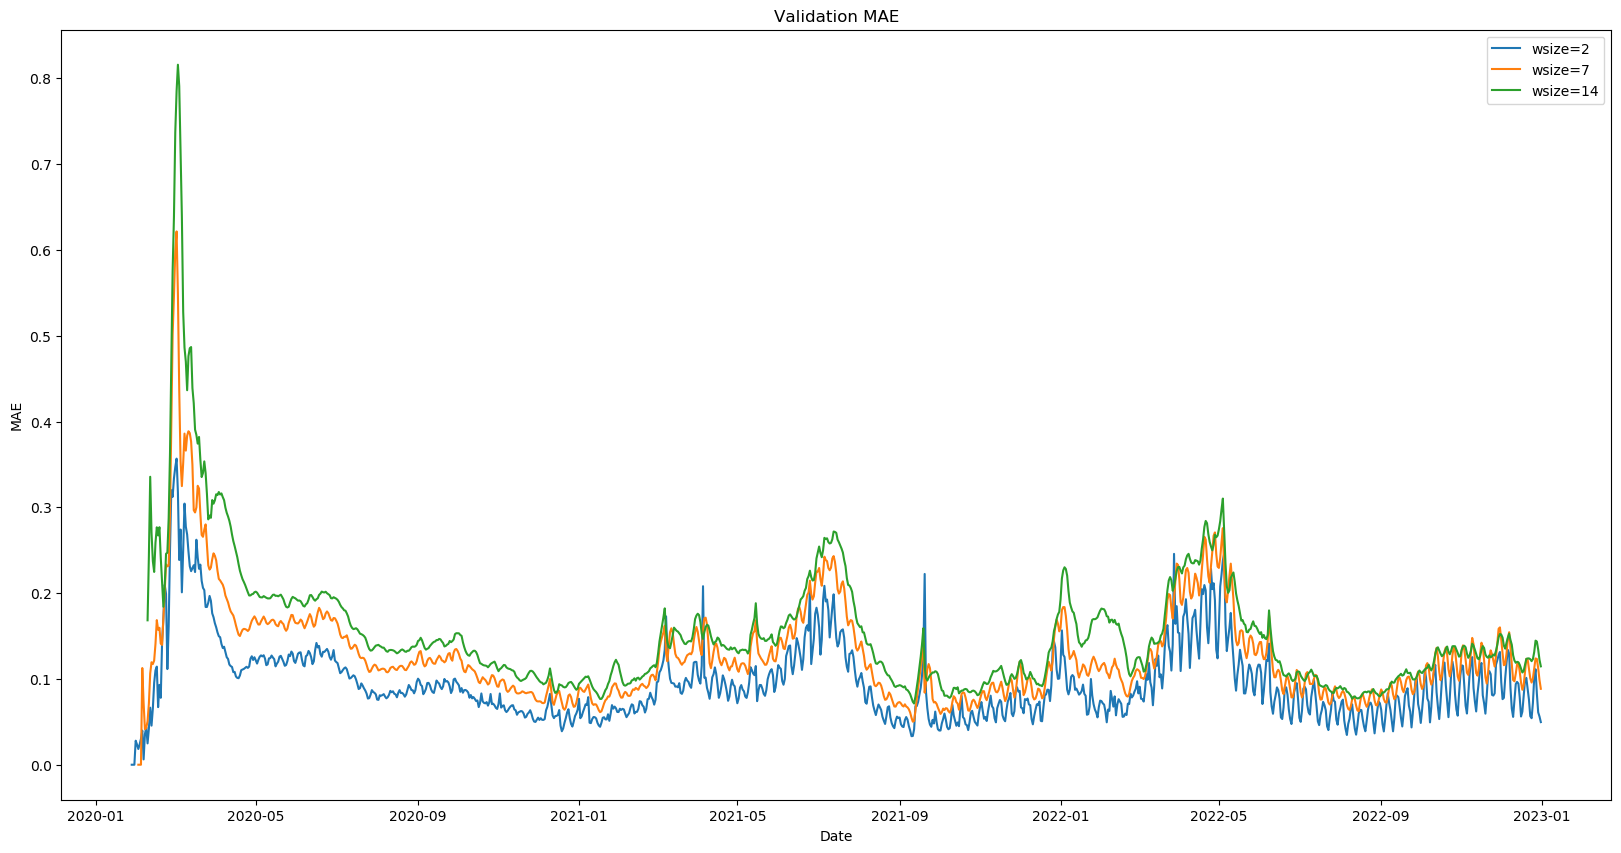

In [14]:
plt.figure(figsize=(20,10))
for wsize in [2,7,14]:
    plt.plot(daily_metrics_df["date"], daily_metrics_df["mae_wsize={}".format(wsize)], label="wsize={}".format(wsize))
    plt.xlabel("Date")
    plt.ylabel("MAE")
    plt.legend()
    plt.title("Validation MAE")
plt.show()

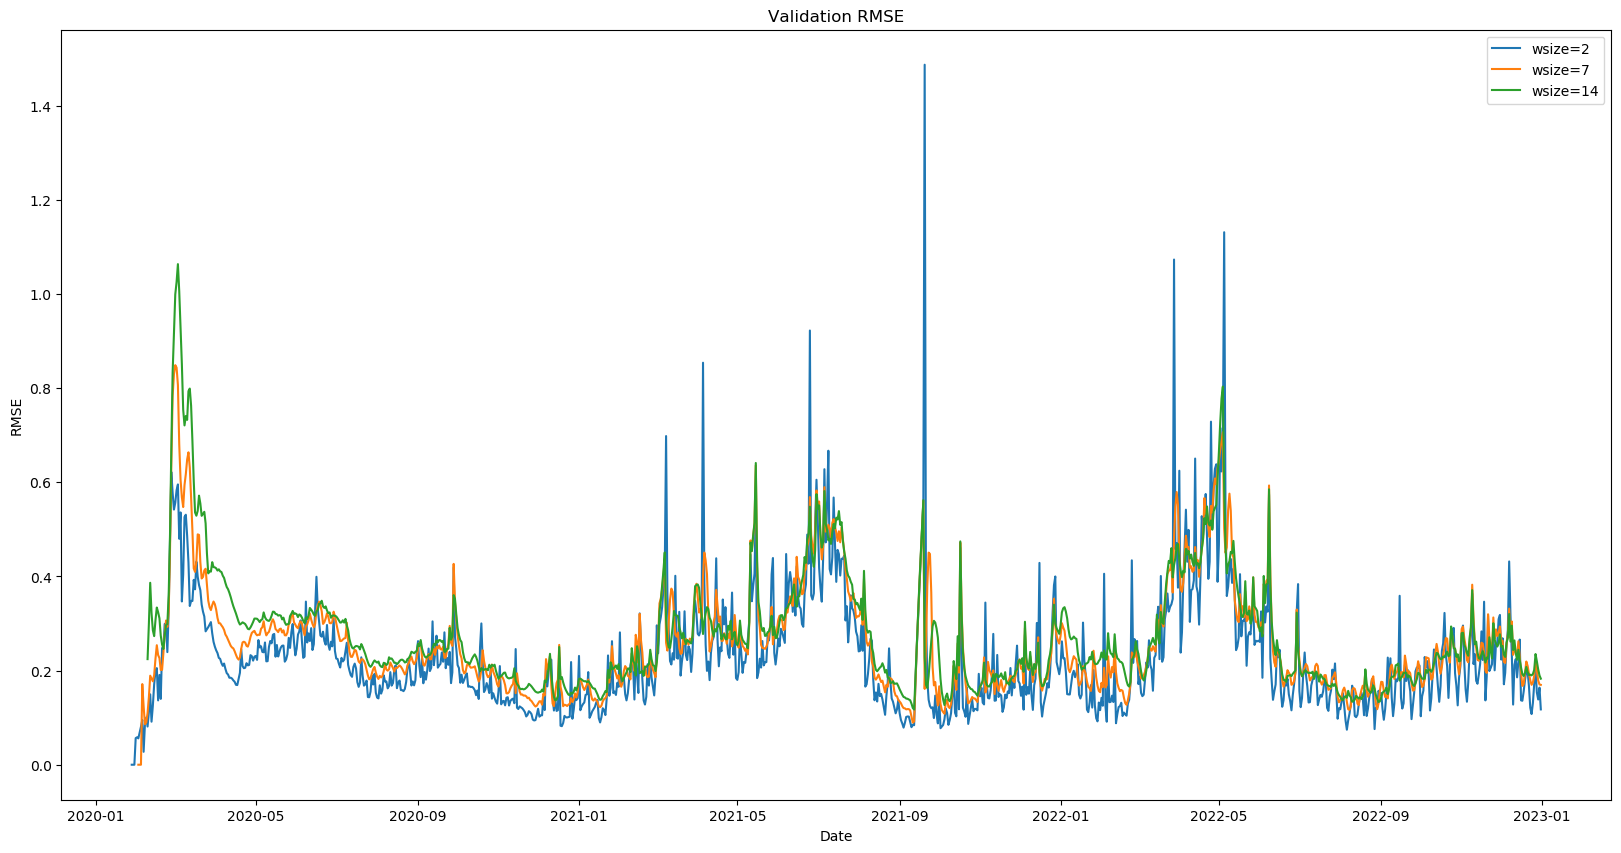

In [15]:
plt.figure(figsize=(20,10))
for wsize in [2,7,14]:
    plt.plot(daily_metrics_df["date"], daily_metrics_df["rmse_wsize={}".format(wsize)], label="wsize={}".format(wsize))
    plt.xlabel("Date")
    plt.ylabel("RMSE")
    plt.legend()
    plt.title("Validation RMSE")
plt.show()

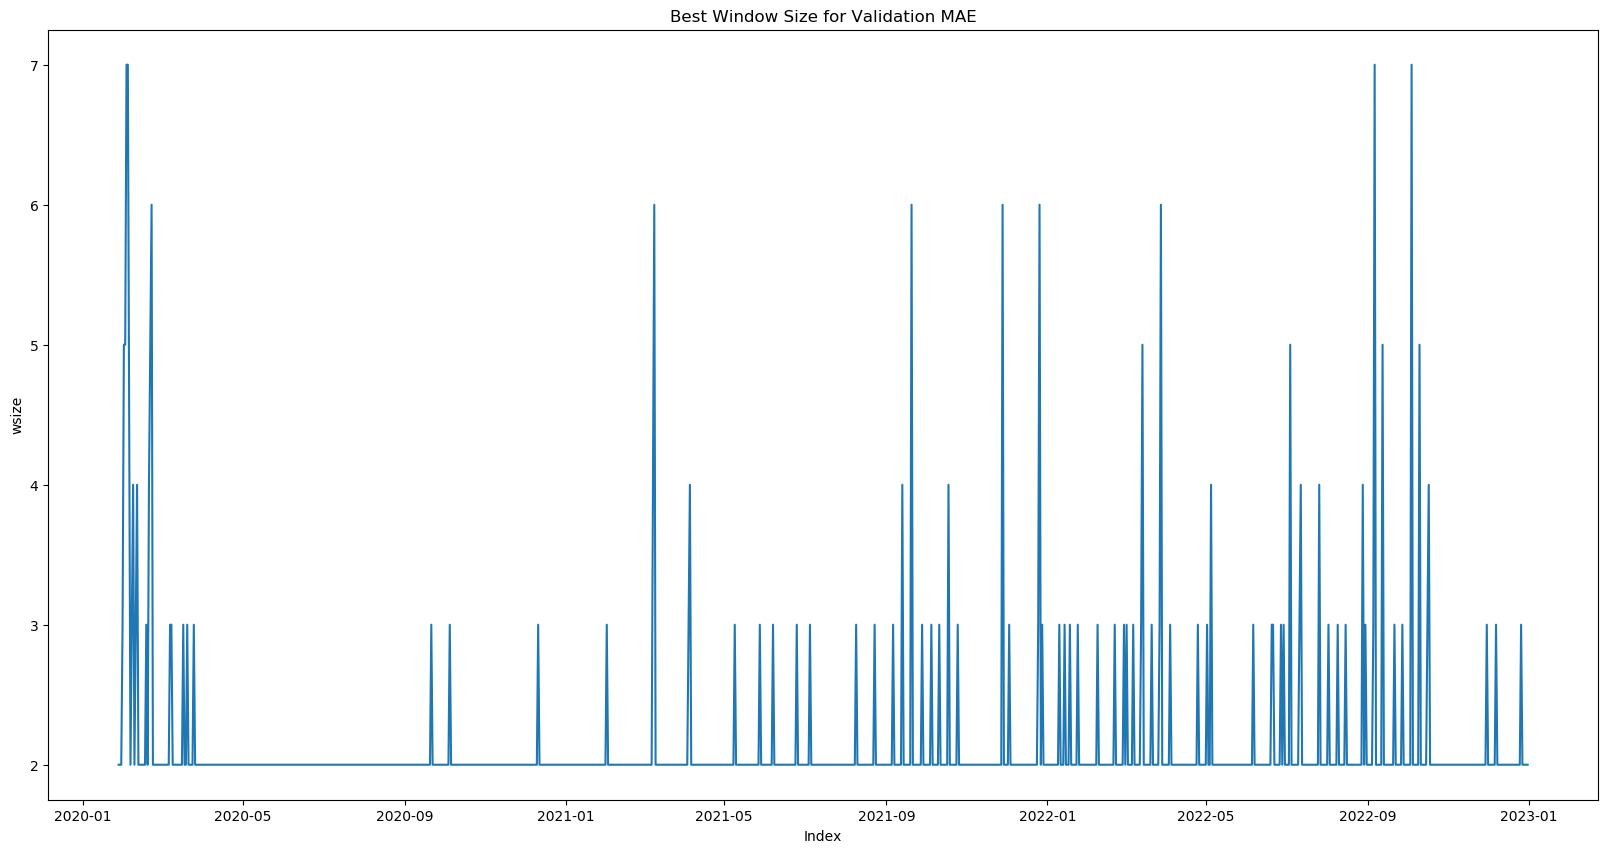

In [16]:
best_wsizes_mae = pd.DataFrame(daily_metrics_df["date"])
daily_mae_df = daily_metrics_df[["mae_wsize={}".format(window_size) for window_size in window_sizes]]
best_wsizes_mae["window"] = daily_mae_df.idxmin(axis=1).str[-1]
best_wsizes_mae = best_wsizes_mae[~best_wsizes_mae["window"].isna()]
best_wsizes_mae["window"] = best_wsizes_mae["window"].astype(np.int64)
best_wsizes_mae = best_wsizes_mae[best_wsizes_mae["window"] >= 2]

plt.figure(figsize=(20,10))
plt.plot(best_wsizes_mae["date"], best_wsizes_mae["window"])
plt.xlabel("Index")
plt.ylabel("wsize")
plt.title("Best Window Size for Validation MAE")

plt.show()

In [17]:
best_wsizes_mae["window"].value_counts()

2    978
3     61
4     12
5      7
6      6
7      4
Name: window, dtype: int64

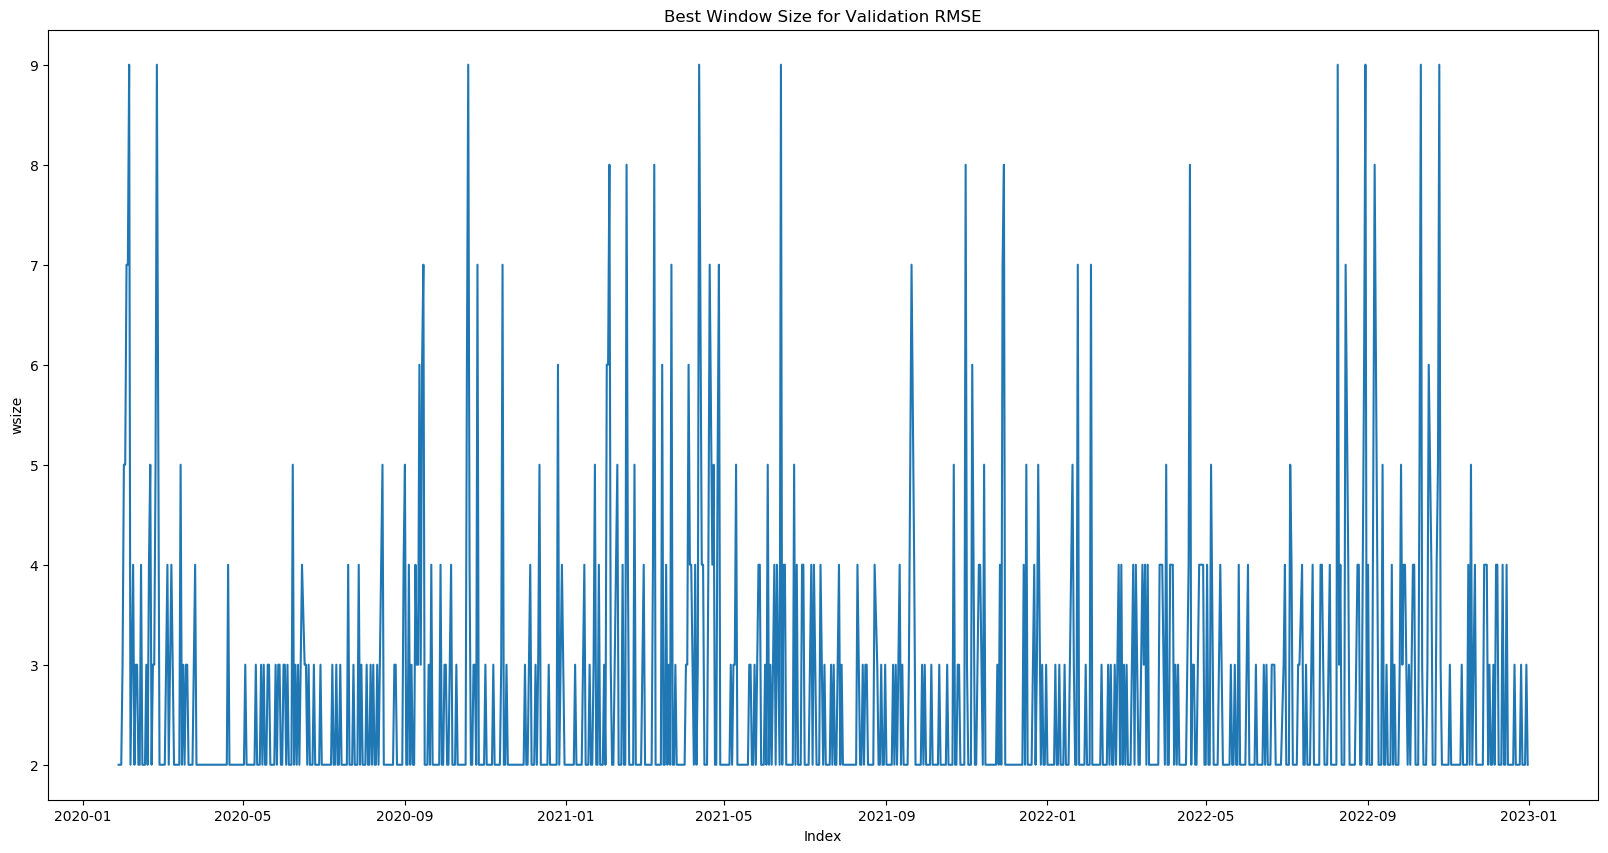

In [18]:
best_wsizes_rmse = pd.DataFrame(daily_metrics_df["date"])
daily_rmse_df = daily_metrics_df[["rmse_wsize={}".format(window_size) for window_size in window_sizes]]
best_wsizes_rmse["window"] = daily_rmse_df.idxmin(axis=1).str[-1]
best_wsizes_rmse = best_wsizes_rmse[~best_wsizes_rmse["window"].isna()]
best_wsizes_rmse["window"] = best_wsizes_rmse["window"].astype(np.int64)
best_wsizes_rmse = best_wsizes_rmse[best_wsizes_rmse["window"]>=2]


plt.figure(figsize=(20,10))
plt.plot(best_wsizes_rmse["date"], best_wsizes_rmse["window"])
plt.xlabel("Index")
plt.ylabel("wsize")
plt.title("Best Window Size for Validation RMSE")

plt.show()

In [19]:
best_wsizes_rmse

,date,window
1,2020-01-28,2
2,2020-01-29,2
3,2020-01-30,2
4,2020-01-31,3
5,2020-02-01,5
...,...,...
1065,2022-12-27,2
1066,2022-12-28,2
1067,2022-12-29,2
1068,2022-12-30,3


In [20]:
best_wsizes_rmse["window"].value_counts()

2    679
3    186
4    110
5     32
7     13
6     11
9      9
8      7
Name: window, dtype: int64

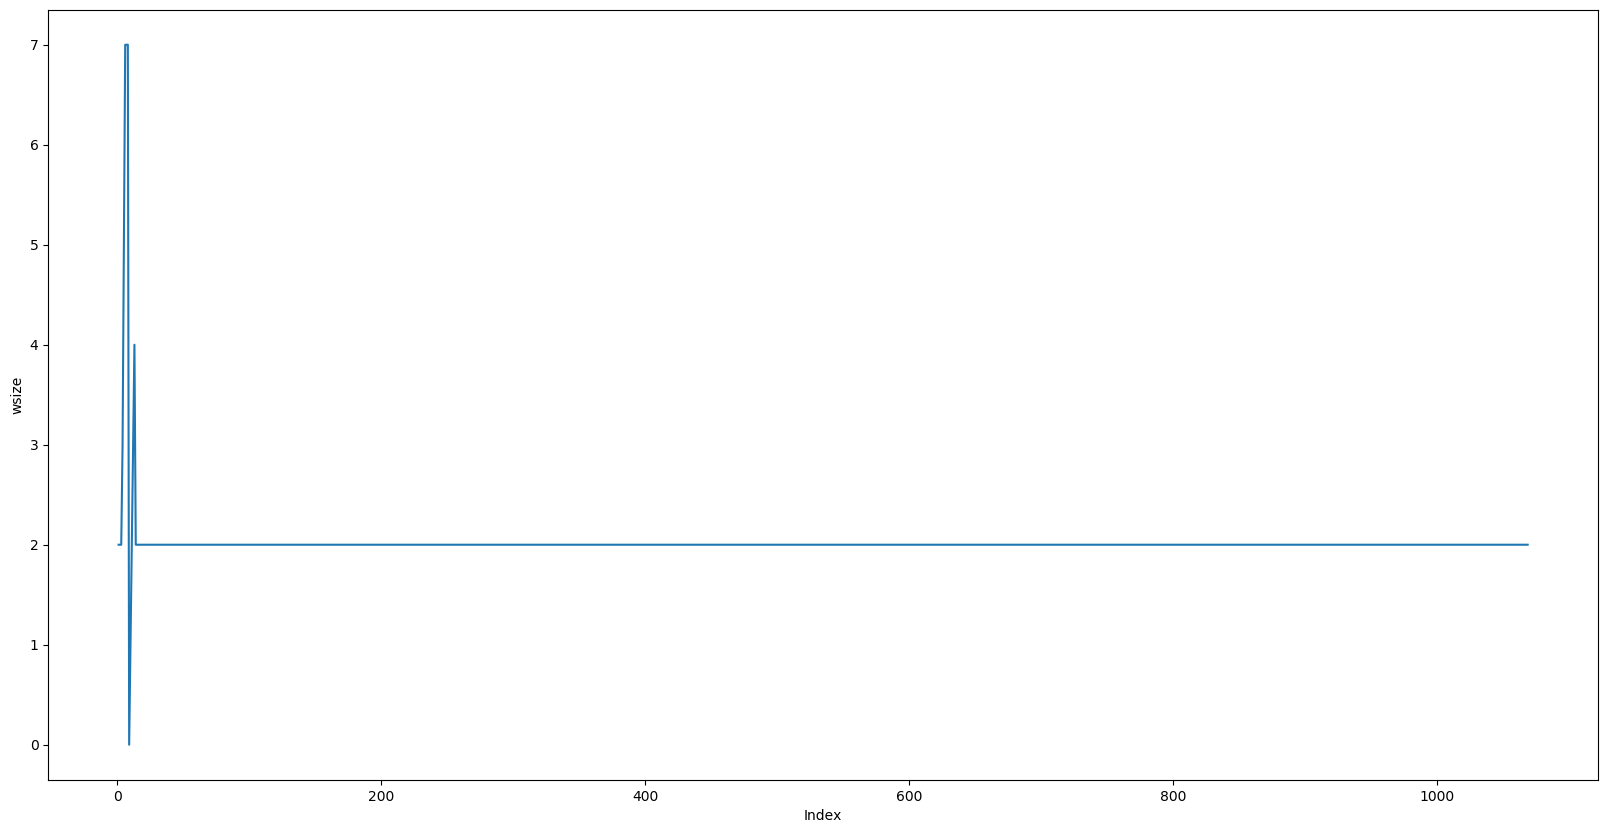

In [21]:
daily_cumsum_mae_df = daily_metrics_df[["cumsum_mae_wsize={}".format(window_size) for window_size in window_sizes]]
best_wsizes_cumsum_mae = daily_cumsum_mae_df.idxmin(axis=1).str[-1]

plt.figure(figsize=(20,10))
plt.plot(best_wsizes_cumsum_mae)
plt.xlabel("Index")
plt.ylabel("wsize")
plt.show()

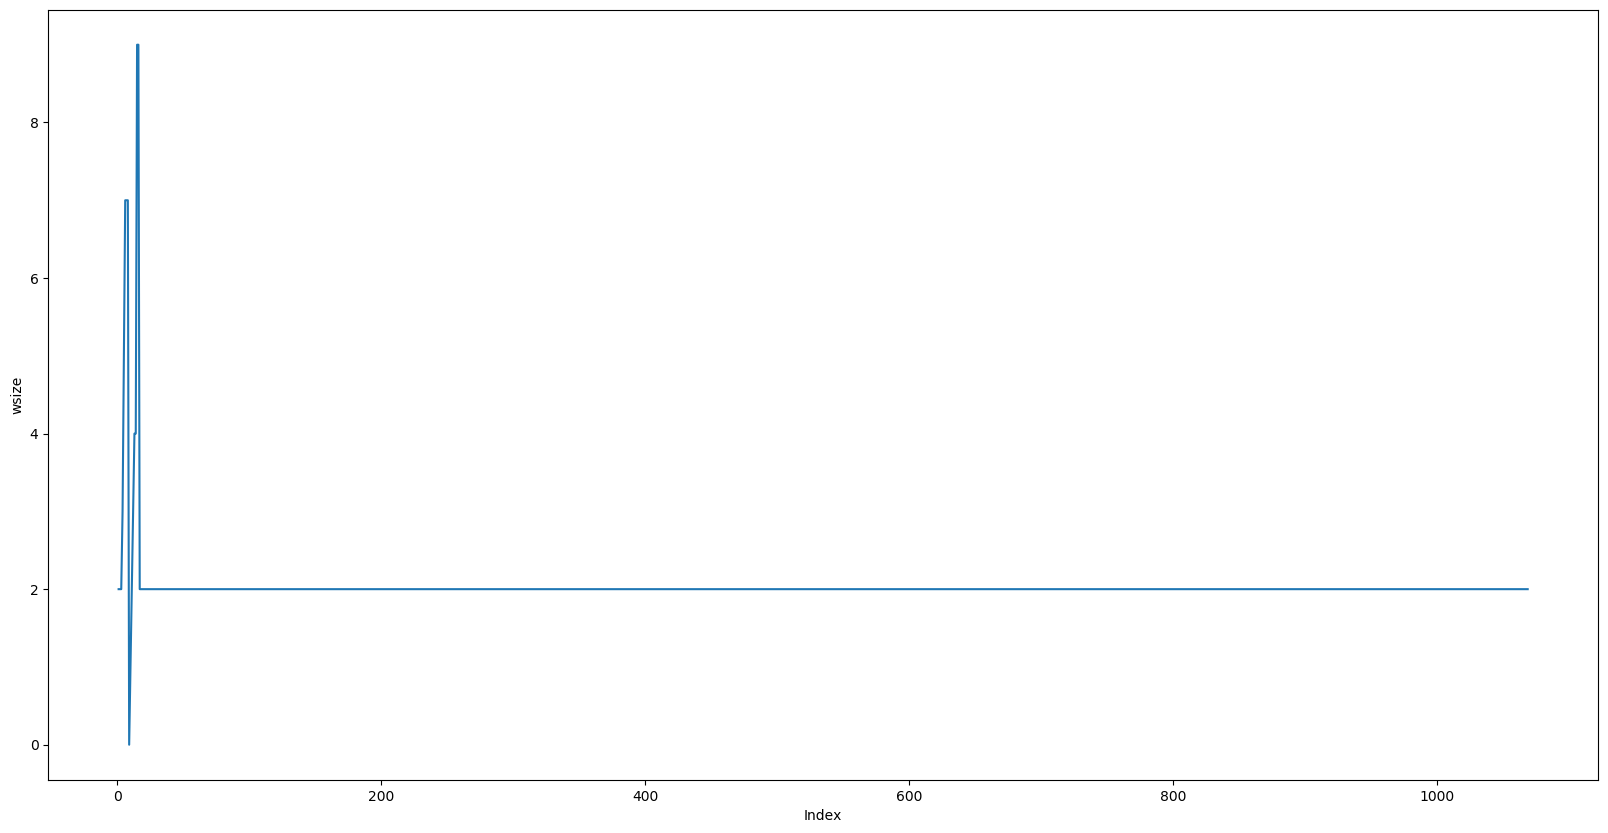

In [22]:
daily_cumsum_rmse_df = daily_metrics_df[["cumsum_rmse_wsize={}".format(window_size) for window_size in window_sizes]]
best_wsizes_cumsum_rmse = daily_cumsum_rmse_df.idxmin(axis=1).str[-1]

plt.figure(figsize=(20,10))
plt.plot(best_wsizes_cumsum_rmse)
plt.xlabel("Index")
plt.ylabel("wsize")
plt.show()

### Try Using Myopically Changing RMSE

In [23]:
best_wsizes_rmse_predict = best_wsizes_rmse.copy()
best_wsizes_rmse_predict["date_query"] = best_wsizes_rmse_predict["date"] + pd.Timedelta(7,unit="d")
best_wsizes_rmse_predict["diff_name"] = best_wsizes_rmse_predict['window'].apply(lambda x: "diff_wsize={}_shift=7".format(x))

# We're interested in diff_wsize={}_shift=7.format(window)
#best_diff_df = all_beta_df_results[["fips","days_from_start","date"]]
best_wsizes_rmse_predict = best_wsizes_rmse_predict[~best_wsizes_rmse_predict["diff_name"].str.contains('diff_wsize=0') ]
best_wsizes_rmse_predict = best_wsizes_rmse_predict[~best_wsizes_rmse_predict["diff_name"].str.contains('diff_wsize=1') ]
best_wsizes_rmse_predict

,date,window,date_query,diff_name
1,2020-01-28,2,2020-02-04,diff_wsize=2_shift=7
2,2020-01-29,2,2020-02-05,diff_wsize=2_shift=7
3,2020-01-30,2,2020-02-06,diff_wsize=2_shift=7
4,2020-01-31,3,2020-02-07,diff_wsize=3_shift=7
5,2020-02-01,5,2020-02-08,diff_wsize=5_shift=7
...,...,...,...,...
1065,2022-12-27,2,2023-01-03,diff_wsize=2_shift=7
1066,2022-12-28,2,2023-01-04,diff_wsize=2_shift=7
1067,2022-12-29,2,2023-01-05,diff_wsize=2_shift=7
1068,2022-12-30,3,2023-01-06,diff_wsize=3_shift=7


In [24]:
all_beta_df_results.columns

Index(['fips', 'days_from_start', 'date', 'log_rolled_cases',
       'shifted_log_rolled_cases_1', 'shifted_log_rolled_cases_2',
       'shifted_log_rolled_cases_3', 'shifted_log_rolled_cases_4',
       'shifted_log_rolled_cases_5', 'shifted_log_rolled_cases_6',
       ...
       'diff_wsize=13_shift=5', 'diff_wsize=13_shift=6',
       'diff_wsize=13_shift=7', 'diff_wsize=14_shift=1',
       'diff_wsize=14_shift=2', 'diff_wsize=14_shift=3',
       'diff_wsize=14_shift=4', 'diff_wsize=14_shift=5',
       'diff_wsize=14_shift=6', 'diff_wsize=14_shift=7'],
      dtype='object', length=206)

In [25]:
by_rmse_merged_df = best_wsizes_rmse_predict.merge(all_beta_df_results, left_on='date_query', right_on='date')
by_rmse_merged_df

,date_x,window,date_query,diff_name,fips,days_from_start,date_y,log_rolled_cases,shifted_log_rolled_cases_1,shifted_log_rolled_cases_2,shifted_log_rolled_cases_3,shifted_log_rolled_cases_4,shifted_log_rolled_cases_5,shifted_log_rolled_cases_6,shifted_log_rolled_cases_7,beta_wsize=2,beta_wsize=3,beta_wsize=4,beta_wsize=5,beta_wsize=6,beta_wsize=7,beta_wsize=8,beta_wsize=9,beta_wsize=10,beta_wsize=11,beta_wsize=12,beta_wsize=13,beta_wsize=14,predicted_beta_wsize=2_shift=1,predicted_beta_wsize=2_shift=2,predicted_beta_wsize=2_shift=3,predicted_beta_wsize=2_shift=4,predicted_beta_wsize=2_shift=5,predicted_beta_wsize=2_shift=6,predicted_beta_wsize=2_shift=7,predicted_beta_wsize=3_shift=1,predicted_beta_wsize=3_shift=2,predicted_beta_wsize=3_shift=3,predicted_beta_wsize=3_shift=4,predicted_beta_wsize=3_shift=5,predicted_beta_wsize=3_shift=6,predicted_beta_wsize=3_shift=7,predicted_beta_wsize=4_shift=1,predicted_beta_wsize=4_shift=2,predicted_beta_wsize=4_shift=3,predicted_beta_wsize=4_shift=4,predicted_beta_wsize=4_shift=5,predicted_beta_wsize=4_shift=6,predicted_beta_wsize=4_shift=7,predicted_beta_wsize=5_shift=1,predicted_beta_wsize=5_shift=2,predicted_beta_wsize=5_shift=3,predicted_beta_wsize=5_shift=4,predicted_beta_wsize=5_shift=5,predicted_beta_wsize=5_shift=6,predicted_beta_wsize=5_shift=7,predicted_beta_wsize=6_shift=1,predicted_beta_wsize=6_shift=2,predicted_beta_wsize=6_shift=3,predicted_beta_wsize=6_shift=4,predicted_beta_wsize=6_shift=5,predicted_beta_wsize=6_shift=6,predicted_beta_wsize=6_shift=7,predicted_beta_wsize=7_shift=1,predicted_beta_wsize=7_shift=2,predicted_beta_wsize=7_shift=3,predicted_beta_wsize=7_shift=4,predicted_beta_wsize=7_shift=5,predicted_beta_wsize=7_shift=6,predicted_beta_wsize=7_shift=7,predicted_beta_wsize=8_shift=1,predicted_beta_wsize=8_shift=2,predicted_beta_wsize=8_shift=3,predicted_beta_wsize=8_shift=4,predicted_beta_wsize=8_shift=5,predicted_beta_wsize=8_shift=6,predicted_beta_wsize=8_shift=7,predicted_beta_wsize=9_shift=1,predicted_beta_wsize=9_shift=2,predicted_beta_wsize=9_shift=3,predicted_beta_wsize=9_shift=4,predicted_beta_wsize=9_shift=5,predicted_beta_wsize=9_shift=6,predicted_beta_wsize=9_shift=7,predicted_beta_wsize=10_shift=1,predicted_beta_wsize=10_shift=2,predicted_beta_wsize=10_shift=3,predicted_beta_wsize=10_shift=4,predicted_beta_wsize=10_shift=5,predicted_beta_wsize=10_shift=6,predicted_beta_wsize=10_shift=7,predicted_beta_wsize=11_shift=1,predicted_beta_wsize=11_shift=2,predicted_beta_wsize=11_shift=3,predicted_beta_wsize=11_shift=4,predicted_beta_wsize=11_shift=5,predicted_beta_wsize=11_shift=6,predicted_beta_wsize=11_shift=7,predicted_beta_wsize=12_shift=1,predicted_beta_wsize=12_shift=2,predicted_beta_wsize=12_shift=3,predicted_beta_wsize=12_shift=4,predicted_beta_wsize=12_shift=5,predicted_beta_wsize=12_shift=6,predicted_beta_wsize=12_shift=7,predicted_beta_wsize=13_shift=1,predicted_beta_wsize=13_shift=2,predicted_beta_wsize=13_shift=3,predicted_beta_wsize=13_shift=4,predicted_beta_wsize=13_shift=5,predicted_beta_wsize=13_shift=6,predicted_beta_wsize=13_shift=7,predicted_beta_wsize=14_shift=1,predicted_beta_wsize=14_shift=2,predicted_beta_wsize=14_shift=3,predicted_beta_wsize=14_shift=4,predicted_beta_wsize=14_shift=5,predicted_beta_wsize=14_shift=6,predicted_beta_wsize=14_shift=7,diff_wsize=2_shift=1,diff_wsize=2_shift=2,diff_wsize=2_shift=3,diff_wsize=2_shift=4,diff_wsize=2_shift=5,diff_wsize=2_shift=6,diff_wsize=2_shift=7,diff_wsize=3_shift=1,diff_wsize=3_shift=2,diff_wsize=3_shift=3,diff_wsize=3_shift=4,diff_wsize=3_shift=5,diff_wsize=3_shift=6,diff_wsize=3_shift=7,diff_wsize=4_shift=1,diff_wsize=4_shift=2,diff_wsize=4_shift=3,diff_wsize=4_shift=4,diff_wsize=4_shift=5,diff_wsize=4_shift=6,diff_wsize=4_shift=7,diff_wsize=5_shift=1,diff_wsize=5_shift=2,diff_wsize=5_shift=3,diff_wsize=5_shift=4,diff_wsize=5_shift=5,diff_wsize=5_shift=6,diff_wsize=5_shift=7,diff_wsize=6_shift=1,diff_wsize=6_shift=2,diff_wsize=6_shift=3,diff_wsize=6_shift=4,diff_wsize=6_shift=5,diff_ws

In [26]:
tcv_by_rmse_MAE = by_rmse_merged_df.groupby("date_query").apply(lambda x : np.nanmean(np.abs(x[x["diff_name"].unique()[0]].values) )).reset_index()
tcv_by_rmse_RMSE = by_rmse_merged_df.groupby("date_query").apply(lambda x : np.sqrt(np.nanmean(np.square(x[x["diff_name"].unique()[0]].values) ))).reset_index()

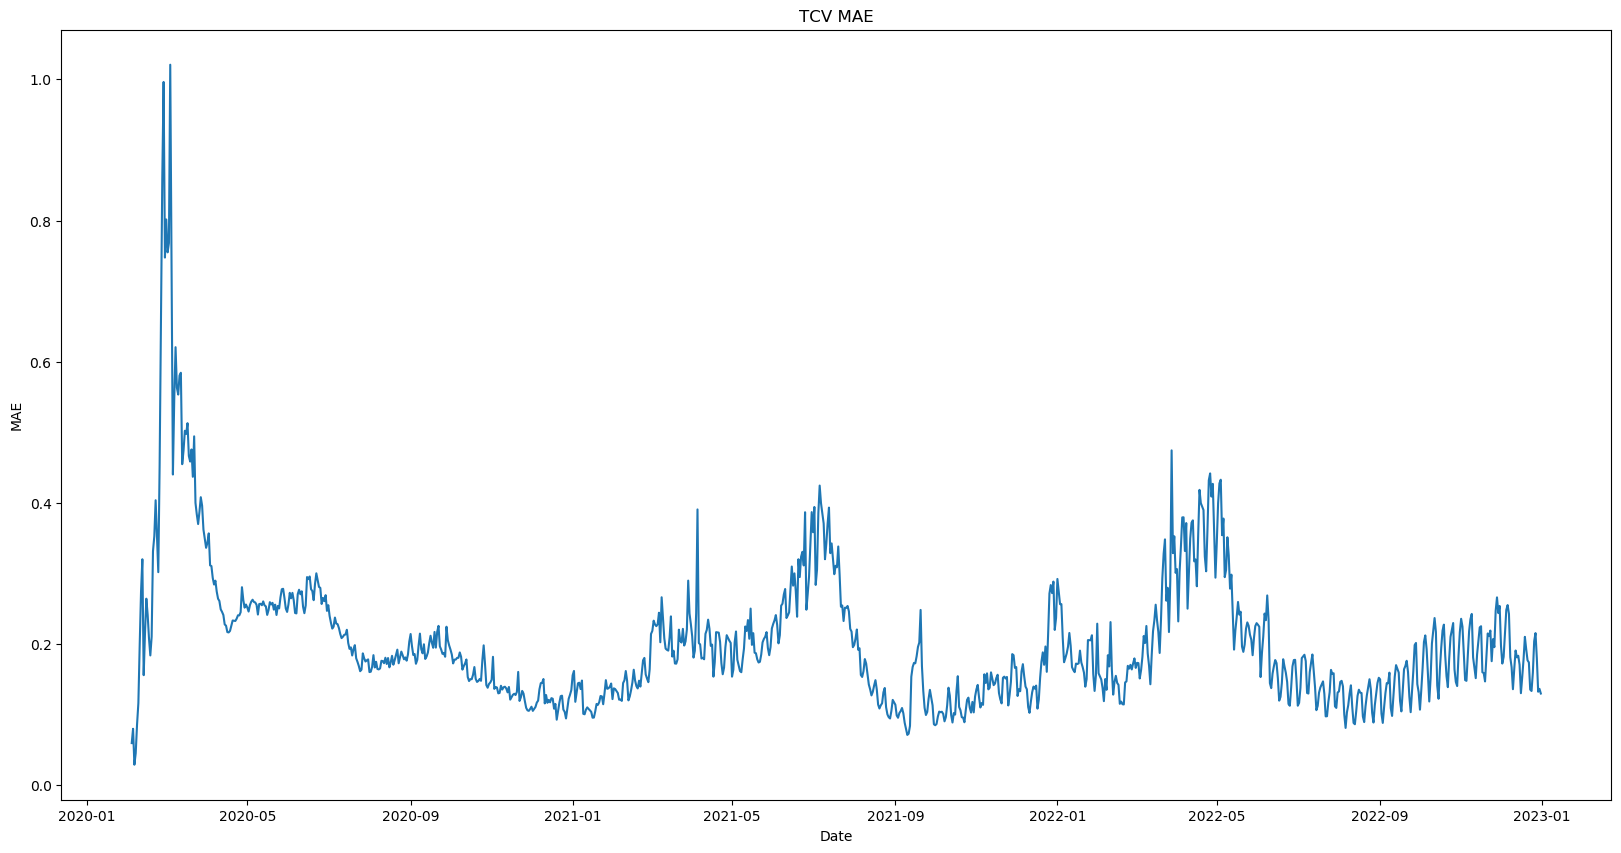

In [27]:
plt.figure(figsize=(20,10))
plt.plot(tcv_by_rmse_MAE["date_query"], tcv_by_rmse_MAE[0])
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("TCV MAE")
plt.show()

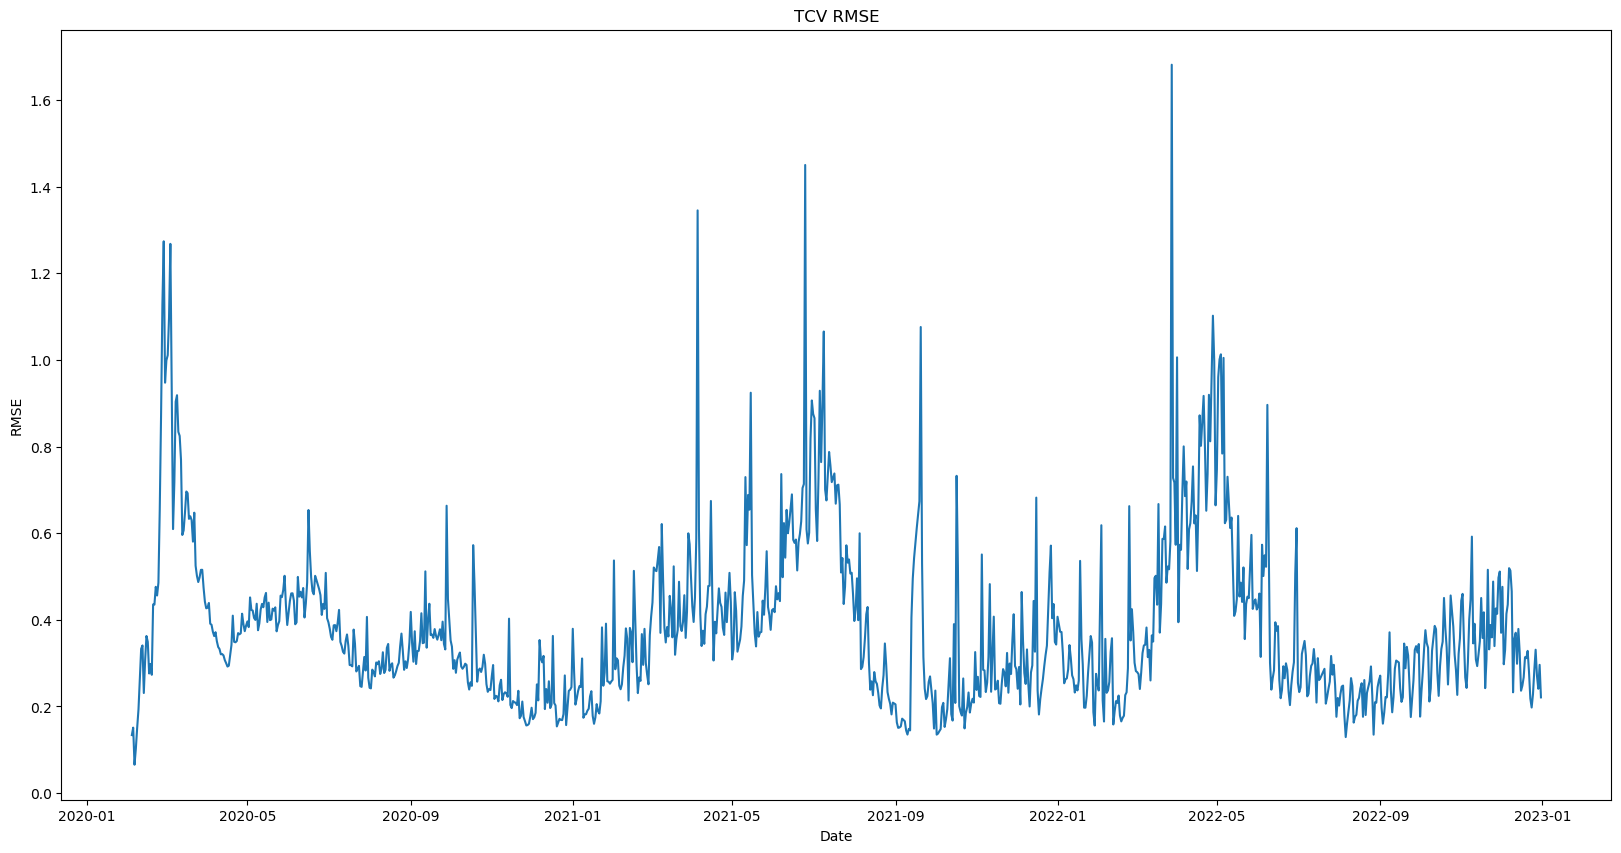

In [28]:
plt.figure(figsize=(20,10))
plt.plot(tcv_by_rmse_RMSE["date_query"], tcv_by_rmse_RMSE[0])
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("TCV RMSE")
plt.show()

### Now for MAE

In [29]:
best_wsizes_mae_predict = best_wsizes_mae.copy()
best_wsizes_mae_predict["date_query"] = best_wsizes_mae_predict["date"] + pd.Timedelta(7,unit="d")
best_wsizes_mae_predict["diff_name"] = best_wsizes_mae_predict['window'].apply(lambda x: "diff_wsize={}_shift=7".format(x))

# We're interested in diff_wsize={}_shift=7.format(window)
#best_diff_df = all_beta_df_results[["fips","days_from_start","date"]]
best_wsizes_mae_predict = best_wsizes_mae_predict[~best_wsizes_mae_predict["diff_name"].str.contains('diff_wsize=0') ]
best_wsizes_mae_predict = best_wsizes_mae_predict[~best_wsizes_mae_predict["diff_name"].str.contains('diff_wsize=1') ]
best_wsizes_mae_predict

,date,window,date_query,diff_name
1,2020-01-28,2,2020-02-04,diff_wsize=2_shift=7
2,2020-01-29,2,2020-02-05,diff_wsize=2_shift=7
3,2020-01-30,2,2020-02-06,diff_wsize=2_shift=7
4,2020-01-31,3,2020-02-07,diff_wsize=3_shift=7
5,2020-02-01,5,2020-02-08,diff_wsize=5_shift=7
...,...,...,...,...
1065,2022-12-27,2,2023-01-03,diff_wsize=2_shift=7
1066,2022-12-28,2,2023-01-04,diff_wsize=2_shift=7
1067,2022-12-29,2,2023-01-05,diff_wsize=2_shift=7
1068,2022-12-30,2,2023-01-06,diff_wsize=2_shift=7


In [30]:
by_mae_merged_df = best_wsizes_mae_predict.merge(all_beta_df_results, left_on='date_query', right_on='date')
by_mae_merged_df

,date_x,window,date_query,diff_name,fips,days_from_start,date_y,log_rolled_cases,shifted_log_rolled_cases_1,shifted_log_rolled_cases_2,shifted_log_rolled_cases_3,shifted_log_rolled_cases_4,shifted_log_rolled_cases_5,shifted_log_rolled_cases_6,shifted_log_rolled_cases_7,beta_wsize=2,beta_wsize=3,beta_wsize=4,beta_wsize=5,beta_wsize=6,beta_wsize=7,beta_wsize=8,beta_wsize=9,beta_wsize=10,beta_wsize=11,beta_wsize=12,beta_wsize=13,beta_wsize=14,predicted_beta_wsize=2_shift=1,predicted_beta_wsize=2_shift=2,predicted_beta_wsize=2_shift=3,predicted_beta_wsize=2_shift=4,predicted_beta_wsize=2_shift=5,predicted_beta_wsize=2_shift=6,predicted_beta_wsize=2_shift=7,predicted_beta_wsize=3_shift=1,predicted_beta_wsize=3_shift=2,predicted_beta_wsize=3_shift=3,predicted_beta_wsize=3_shift=4,predicted_beta_wsize=3_shift=5,predicted_beta_wsize=3_shift=6,predicted_beta_wsize=3_shift=7,predicted_beta_wsize=4_shift=1,predicted_beta_wsize=4_shift=2,predicted_beta_wsize=4_shift=3,predicted_beta_wsize=4_shift=4,predicted_beta_wsize=4_shift=5,predicted_beta_wsize=4_shift=6,predicted_beta_wsize=4_shift=7,predicted_beta_wsize=5_shift=1,predicted_beta_wsize=5_shift=2,predicted_beta_wsize=5_shift=3,predicted_beta_wsize=5_shift=4,predicted_beta_wsize=5_shift=5,predicted_beta_wsize=5_shift=6,predicted_beta_wsize=5_shift=7,predicted_beta_wsize=6_shift=1,predicted_beta_wsize=6_shift=2,predicted_beta_wsize=6_shift=3,predicted_beta_wsize=6_shift=4,predicted_beta_wsize=6_shift=5,predicted_beta_wsize=6_shift=6,predicted_beta_wsize=6_shift=7,predicted_beta_wsize=7_shift=1,predicted_beta_wsize=7_shift=2,predicted_beta_wsize=7_shift=3,predicted_beta_wsize=7_shift=4,predicted_beta_wsize=7_shift=5,predicted_beta_wsize=7_shift=6,predicted_beta_wsize=7_shift=7,predicted_beta_wsize=8_shift=1,predicted_beta_wsize=8_shift=2,predicted_beta_wsize=8_shift=3,predicted_beta_wsize=8_shift=4,predicted_beta_wsize=8_shift=5,predicted_beta_wsize=8_shift=6,predicted_beta_wsize=8_shift=7,predicted_beta_wsize=9_shift=1,predicted_beta_wsize=9_shift=2,predicted_beta_wsize=9_shift=3,predicted_beta_wsize=9_shift=4,predicted_beta_wsize=9_shift=5,predicted_beta_wsize=9_shift=6,predicted_beta_wsize=9_shift=7,predicted_beta_wsize=10_shift=1,predicted_beta_wsize=10_shift=2,predicted_beta_wsize=10_shift=3,predicted_beta_wsize=10_shift=4,predicted_beta_wsize=10_shift=5,predicted_beta_wsize=10_shift=6,predicted_beta_wsize=10_shift=7,predicted_beta_wsize=11_shift=1,predicted_beta_wsize=11_shift=2,predicted_beta_wsize=11_shift=3,predicted_beta_wsize=11_shift=4,predicted_beta_wsize=11_shift=5,predicted_beta_wsize=11_shift=6,predicted_beta_wsize=11_shift=7,predicted_beta_wsize=12_shift=1,predicted_beta_wsize=12_shift=2,predicted_beta_wsize=12_shift=3,predicted_beta_wsize=12_shift=4,predicted_beta_wsize=12_shift=5,predicted_beta_wsize=12_shift=6,predicted_beta_wsize=12_shift=7,predicted_beta_wsize=13_shift=1,predicted_beta_wsize=13_shift=2,predicted_beta_wsize=13_shift=3,predicted_beta_wsize=13_shift=4,predicted_beta_wsize=13_shift=5,predicted_beta_wsize=13_shift=6,predicted_beta_wsize=13_shift=7,predicted_beta_wsize=14_shift=1,predicted_beta_wsize=14_shift=2,predicted_beta_wsize=14_shift=3,predicted_beta_wsize=14_shift=4,predicted_beta_wsize=14_shift=5,predicted_beta_wsize=14_shift=6,predicted_beta_wsize=14_shift=7,diff_wsize=2_shift=1,diff_wsize=2_shift=2,diff_wsize=2_shift=3,diff_wsize=2_shift=4,diff_wsize=2_shift=5,diff_wsize=2_shift=6,diff_wsize=2_shift=7,diff_wsize=3_shift=1,diff_wsize=3_shift=2,diff_wsize=3_shift=3,diff_wsize=3_shift=4,diff_wsize=3_shift=5,diff_wsize=3_shift=6,diff_wsize=3_shift=7,diff_wsize=4_shift=1,diff_wsize=4_shift=2,diff_wsize=4_shift=3,diff_wsize=4_shift=4,diff_wsize=4_shift=5,diff_wsize=4_shift=6,diff_wsize=4_shift=7,diff_wsize=5_shift=1,diff_wsize=5_shift=2,diff_wsize=5_shift=3,diff_wsize=5_shift=4,diff_wsize=5_shift=5,diff_wsize=5_shift=6,diff_wsize=5_shift=7,diff_wsize=6_shift=1,diff_wsize=6_shift=2,diff_wsize=6_shift=3,diff_wsize=6_shift=4,diff_wsize=6_shift=5,diff_ws

In [31]:
tcv_by_mae_MAE = by_mae_merged_df.groupby("date_query").apply(lambda x : np.nanmean(np.abs(x[x["diff_name"].unique()[0]].values) )).reset_index()
tcv_by_mae_RMSE = by_mae_merged_df.groupby("date_query").apply(lambda x : np.sqrt(np.nanmean(np.square(x[x["diff_name"].unique()[0]].values) ))).reset_index()

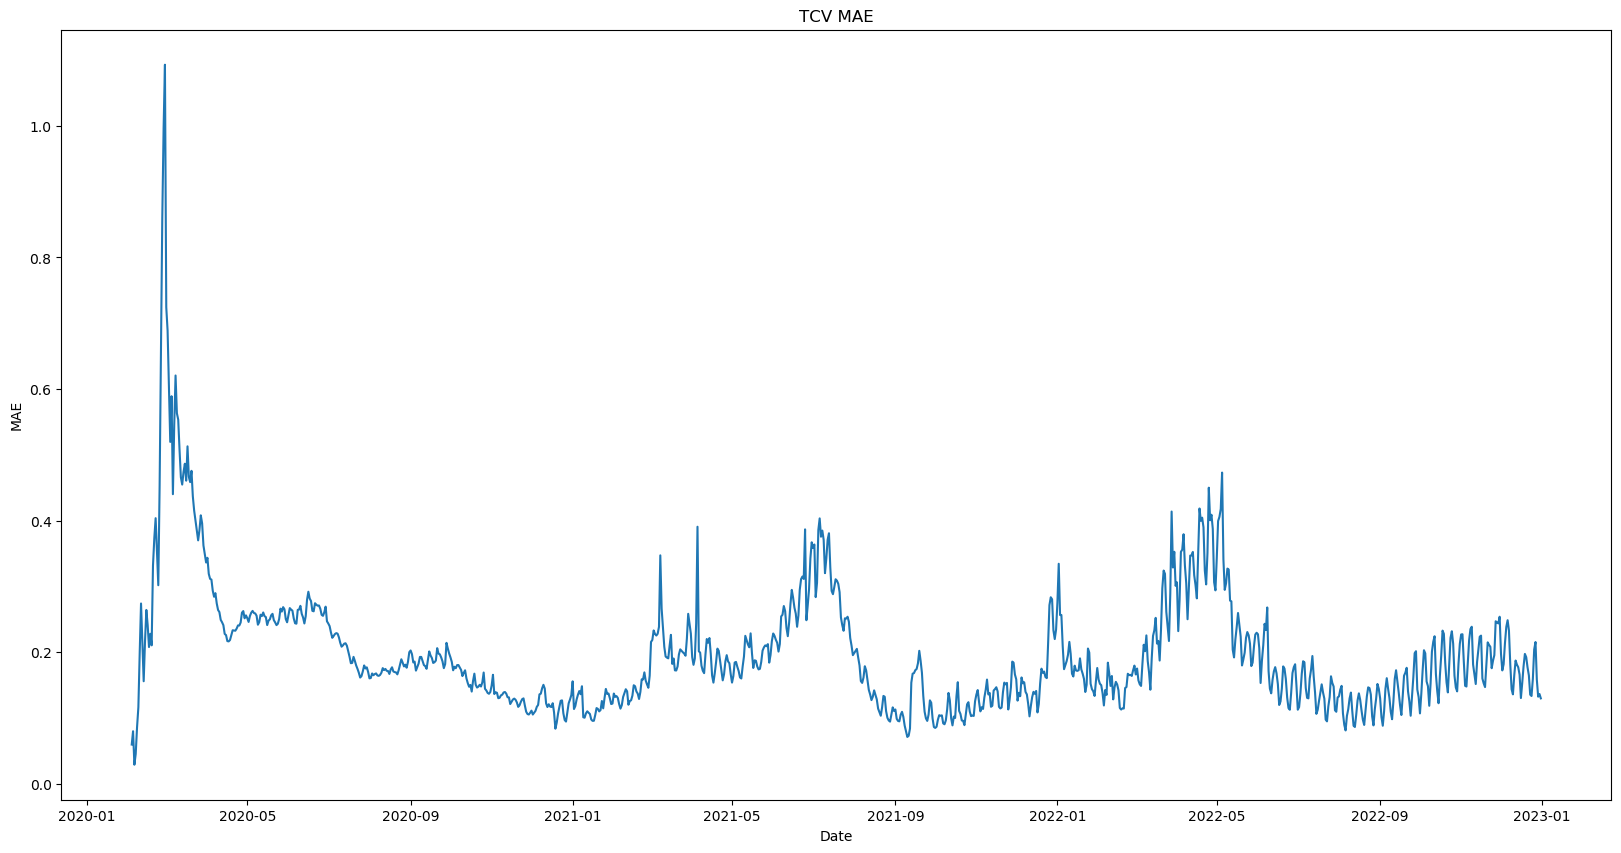

In [32]:
plt.figure(figsize=(20,10))
plt.plot(tcv_by_mae_MAE["date_query"], tcv_by_mae_MAE[0])
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("TCV MAE")
plt.show()

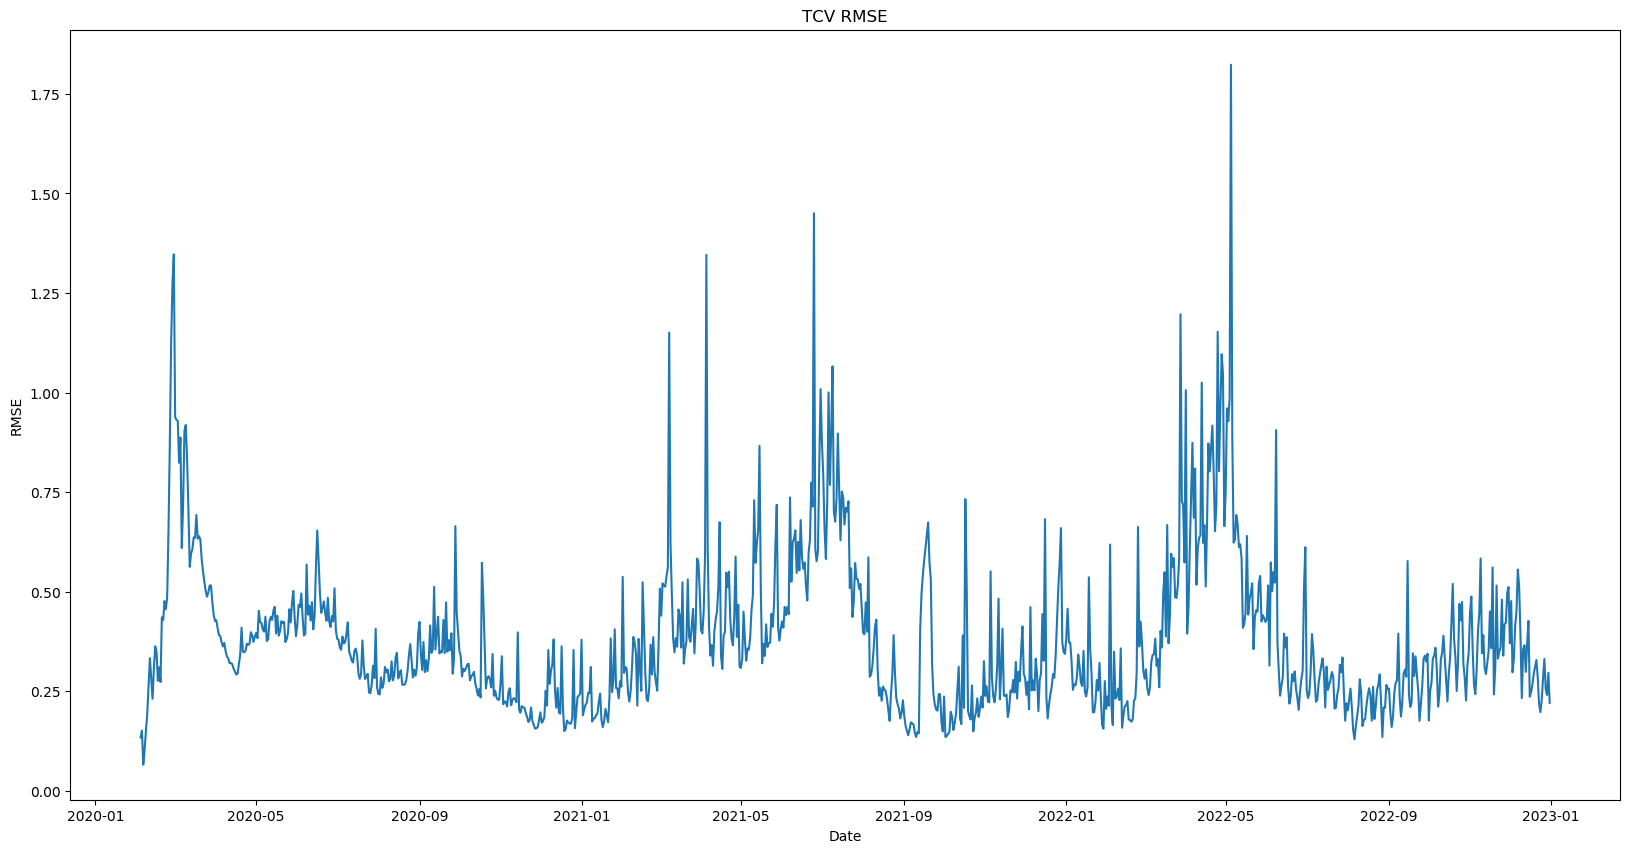

In [33]:
plt.figure(figsize=(20,10))
plt.plot(tcv_by_mae_RMSE["date_query"], tcv_by_mae_RMSE[0])
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("TCV RMSE")
plt.show()

### Overall TCV Results

In [34]:
Fixed_windows_RMSE_df = pd.read_csv("../benchmark_fixed_window/Fixed_windows_RMSE_df.csv")
Fixed_windows_MAE_df = pd.read_csv("../benchmark_fixed_window/Fixed_windows_MAE_df.csv")

Fixed_windows_RMSE_df["date"] = pd.to_datetime(Fixed_windows_RMSE_df["date"])
Fixed_windows_MAE_df["date"] = pd.to_datetime(Fixed_windows_MAE_df["date"])

In [35]:
start_date = Fixed_windows_RMSE_df["date"].min()
start_date

Timestamp('2020-03-06 00:00:00')

In [36]:
fixed_metrics_comparison_df = pd.DataFrame()

row_names = ["TLGRF"] + ["Fixed Window {}".format(window_size) for window_size in window_sizes]

fixed_metrics_comparison_df["MAE"] = Fixed_windows_MAE_df.median()
fixed_metrics_comparison_df["RMSE"] = Fixed_windows_RMSE_df.median()
fixed_metrics_comparison_df.index = row_names
fixed_metrics_comparison_df = fixed_metrics_comparison_df[::-1]
fixed_metrics_comparison_df

,MAE,RMSE
Fixed Window 14,0.239571,0.373409
Fixed Window 13,0.236506,0.372249
Fixed Window 12,0.233919,0.370985
Fixed Window 11,0.231018,0.370864
Fixed Window 10,0.228107,0.370185
Fixed Window 9,0.224462,0.369265
Fixed Window 8,0.220137,0.367783
Fixed Window 7,0.213482,0.364968
Fixed Window 6,0.207550,0.360429
Fixed Window 5,0.199554,0.354074


In [37]:
tcv_metrics_df = pd.DataFrame()

tcv_by_mae_MAE_sliced = tcv_by_mae_MAE[tcv_by_mae_MAE["date_query"] >= start_date]
tcv_by_rmse_MAE_sliced = tcv_by_rmse_MAE[tcv_by_rmse_MAE["date_query"] >= start_date]
tcv_by_mae_RMSE_sliced = tcv_by_mae_RMSE[tcv_by_mae_RMSE["date_query"] >= start_date]
tcv_by_rmse_RMSE_sliced = tcv_by_rmse_RMSE[tcv_by_rmse_RMSE["date_query"] >= start_date]

tcv_metrics_df["MAE"] = [tcv_by_mae_MAE_sliced[0].median(), tcv_by_rmse_MAE_sliced[0].median()]
tcv_metrics_df["RMSE"] = [tcv_by_mae_RMSE_sliced[0].median(), tcv_by_rmse_RMSE_sliced[0].median()]
tcv_metrics_df.index = ["TCV windows chosen via MAE", "TCV windows chosen via RMSE"]
tcv_metrics_df

,MAE,RMSE
TCV windows chosen via MAE,0.175203,0.338574
TCV windows chosen via RMSE,0.178788,0.338974


In [38]:
tcv_metrics_df_old = pd.DataFrame()
end_date = "2021-09-12"
tcv_metrics_df_old["MAE"] = [tcv_by_mae_MAE_sliced[tcv_by_mae_MAE_sliced["date_query"] <= end_date][0].median(), tcv_by_rmse_MAE_sliced[tcv_by_rmse_MAE_sliced["date_query"] <= end_date][0].median()]
tcv_metrics_df_old["RMSE"] = [tcv_by_mae_RMSE_sliced[tcv_by_mae_RMSE_sliced["date_query"] <= end_date][0].median(), tcv_by_rmse_RMSE_sliced[tcv_by_rmse_RMSE_sliced["date_query"] <= end_date][0].median()]
tcv_metrics_df_old.index = ["TCV windows chosen via MAE", "TCV windows chosen via RMSE"]
tcv_metrics_df_old

,MAE,RMSE
TCV windows chosen via MAE,0.187022,0.368443
TCV windows chosen via RMSE,0.193746,0.367604


In [39]:
tcv_by_rmse_MAE_sliced

,date_query,0
30,2020-03-06,0.440284
31,2020-03-07,0.545718
32,2020-03-08,0.620630
33,2020-03-09,0.563316
34,2020-03-10,0.553548
...,...,...
1042,2023-01-03,NaN
1043,2023-01-04,NaN
1044,2023-01-05,NaN
1045,2023-01-06,NaN


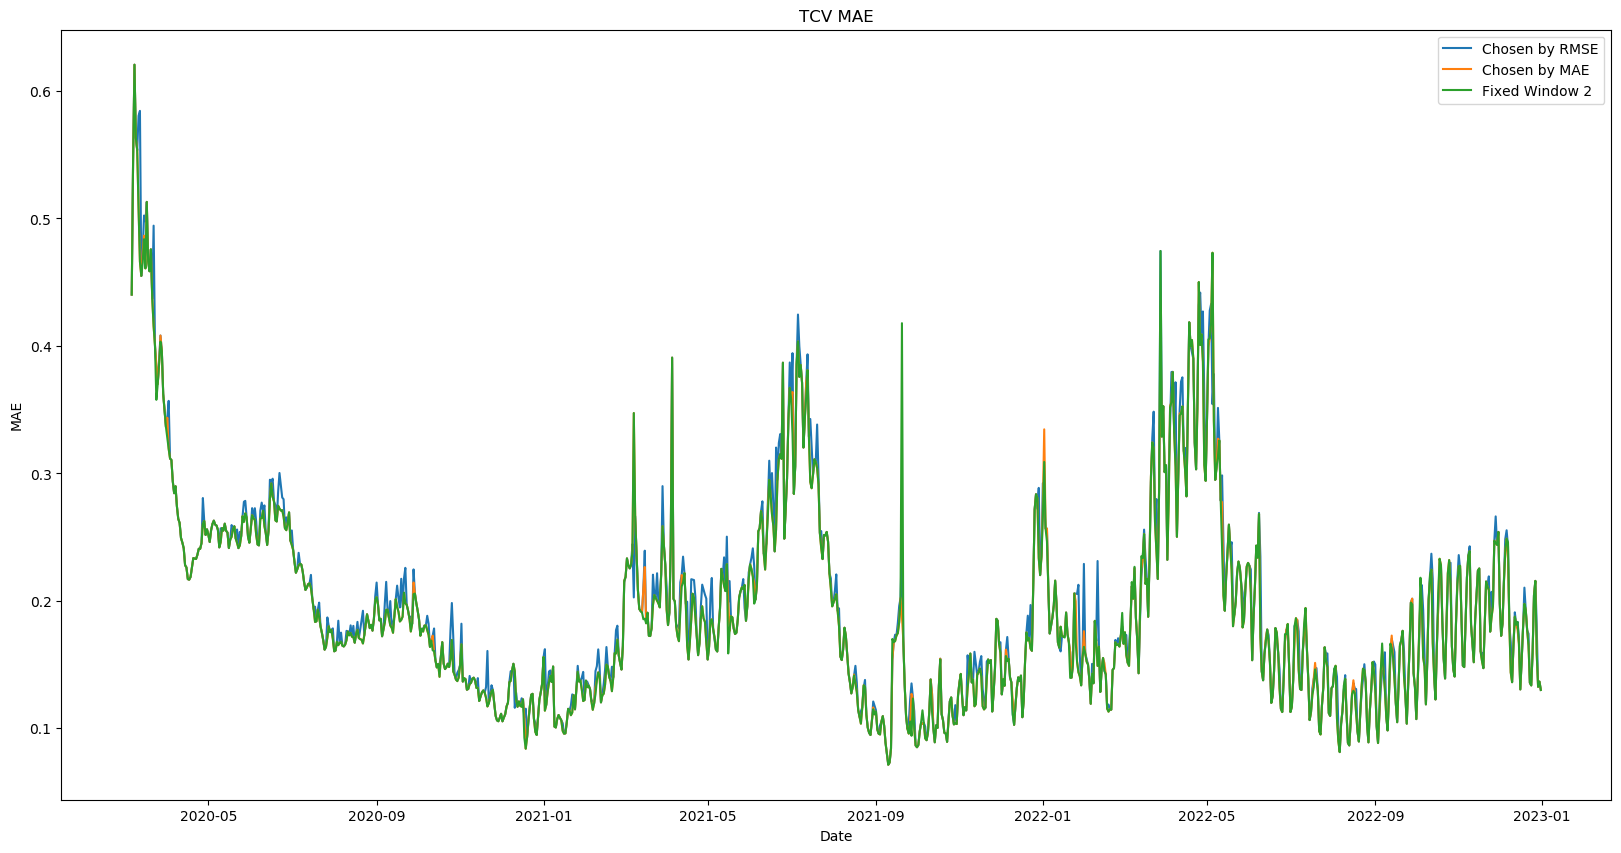

In [40]:
plt.figure(figsize=(20,10))
plt.plot(tcv_by_rmse_MAE_sliced["date_query"], tcv_by_rmse_MAE_sliced[0], label="Chosen by RMSE")
plt.plot(tcv_by_mae_MAE_sliced["date_query"], tcv_by_mae_MAE_sliced[0], label="Chosen by MAE")
plt.plot(Fixed_windows_MAE_df["date"], Fixed_windows_MAE_df["beta_wsize=2"], label="Fixed Window 2")
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("TCV MAE")
plt.legend()
plt.show()

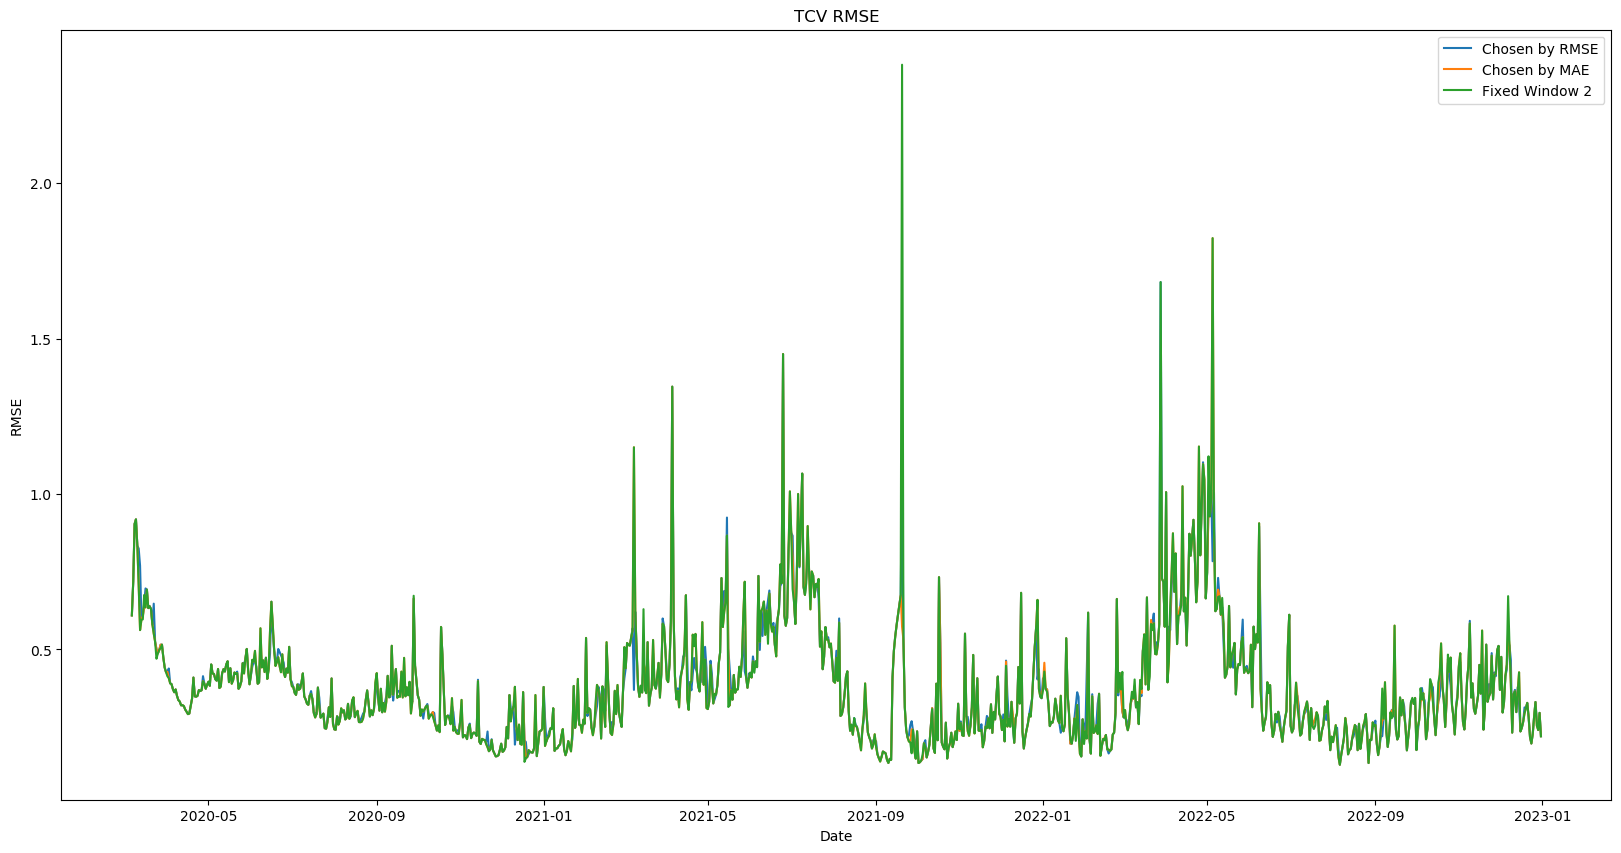

In [41]:
plt.figure(figsize=(20,10))
plt.plot(tcv_by_rmse_RMSE_sliced["date_query"], tcv_by_rmse_RMSE_sliced[0], label="Chosen by RMSE")
plt.plot(tcv_by_mae_RMSE_sliced["date_query"], tcv_by_mae_RMSE_sliced[0], label="Chosen by MAE")
plt.plot(Fixed_windows_RMSE_df["date"], Fixed_windows_RMSE_df["beta_wsize=2"], label="Fixed Window 2")

plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("TCV RMSE")
plt.legend()
plt.show()

### Restrict to `<= 2021-09-12`

In [42]:
fixed_metrics_comparison_df

,MAE,RMSE
Fixed Window 14,0.239571,0.373409
Fixed Window 13,0.236506,0.372249
Fixed Window 12,0.233919,0.370985
Fixed Window 11,0.231018,0.370864
Fixed Window 10,0.228107,0.370185
Fixed Window 9,0.224462,0.369265
Fixed Window 8,0.220137,0.367783
Fixed Window 7,0.213482,0.364968
Fixed Window 6,0.207550,0.360429
Fixed Window 5,0.199554,0.354074


In [43]:
break

SyntaxError: 'break' outside loop (<ipython-input-43-6aaf1f276005>, line 4)

### Save the Shifts Beta

In [ ]:
wsize_shift = itertools.product(list(range(2,15)), list(range(1,8)))
cols_to_keep = ["fips", "days_from_start", "date"] + ["diff_wsize={}_shift={}".format(window_size, shift) for window_size, shift in wsize_shift]
all_beta_df_results_diff = all_beta_df_results[cols_to_keep]
all_beta_df_results_diff
all_beta_df_results_diff.to_csv("Fixed_Windows_Validation_Diff.csv", index=False)

In [ ]:
# [t-6, t-5, t-4, t-3, t-2, t-1, t]
# Let w* be the best window size chosen by validation
# At test time: fit on [t-w*+1,...,t] predict t+7

# Validation ground truth is some combination of subset of [t-6, t-5, t-4, t-3, t-2, t-1, t]
# wsize=2: fit [t-8,t-7] validate on [t]
# [t-9,t-8] validate on [t-1]
# ... 
# [t-15, t-14] validate on [t-6]


# [   ] [   ] [   ]